# **Exploratory Data Analysis: Understanding the Drivers of Agricultural Yield in Maji Ndogo**

<center>
<h1><b> 1. INTRODUCTION</b></h1>
</center>

Agriculture plays a critical role in ensuring food security and economic sustainability. Maximizing crop productivity requires a thorough understanding of how environmental, geographical, and soil-related factors influence agricultural yield. Before developing predictive machine learning models, it is essential to explore the underlying characteristics of the data to identify patterns, validate assumptions, and uncover relationships between variables.

This notebook presents an Exploratory Data Analysis (EDA) of the processed agricultural field and weather datasets for the fictional country of **Maji Ndogo**. The datasets have already undergone data ingestion, cleaning, preprocessing, and feature engineering through dedicated data processing pipelines, resulting in analysis-ready data.

The primary objective of this analysis is to investigate the factors associated with **`Standard_yield`**, which serves as the target variable representing standardized crop productivity. Throughout this notebook, we examine the distribution of the target variable, explore the characteristics of the predictor variables, assess relationships between features, perform statistical hypothesis testing where appropriate, and identify insights that will inform feature engineering and predictive modelling.

The findings from this exploratory analysis will provide a deeper understanding of the dataset, highlight potential drivers of crop productivity.

## 2. Importing Modules
**This section imports essential libraries for data handling, statistical analysis and visualization, along with custom project modules for configuration and processing field and weather data.**


In [1]:
import os
os.chdir("..")

In [4]:
import pandas as pd
import numpy as np
import scipy as scipy
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from src.config import config_params
from src.field_data_processor import FieldDataProcessor
from src.weather_data_processor import WeatherDataProcessor

3. Data Ingestion and Processing

This section initializes custom data processing classes for field and weather data using configuration parameters. 
The process() methods handle data extraction, cleaning, and transformation, after which the processed datasets are stored as structured DataFrames for further analysis.

* `FieldDataProcessor` is used to process field-related data and store the cleaned result in `field_df`.
* `WeatherDataProcessor` processes weather data and stores the aggregated results in `weather_df` (using `mean_df`).
* Finally, `.shape` is printed for both datasets to confirm they were loaded and processed correctly.

In [5]:
field_processor = FieldDataProcessor(config_params)
field_processor.process()
field_df = field_processor.df

weather_processor = WeatherDataProcessor(config_params)
weather_processor.process()
weather_df = weather_processor.mean_df

print(field_df.shape)
print(weather_df.shape)

2026-07-04 22:30:08,324 - data_ingestion - INFO - Successfully connected to: sqlite:///data/Maji_Ndogo_farm_survey_small.db


2026-07-04 22:30:08,392 - data_ingestion - INFO - Query executed. Rows: 5654
2026-07-04 22:30:08,393 - src.field_data_processor.FieldDataProcessor - INFO - SQL data is sucessfully loaded into DataFrame.
2026-07-04 22:30:08,395 - src.field_data_processor.FieldDataProcessor - INFO - Swapped columns: Annual_yield with Crop_type
2026-07-04 22:30:08,397 - src.field_data_processor.FieldDataProcessor - INFO - Converted negative elevation values to absolute as per project specification
2026-07-04 22:30:08,403 - src.field_data_processor.FieldDataProcessor - INFO - Mispelled names and extra whitespaces were found and got fixed
2026-07-04 22:30:08,404 - data_ingestion - INFO - Attempting to read CSV from: https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Maji_Ndogo/Weather_data_field_mapping.csv
2026-07-04 22:30:20,635 - data_ingestion - INFO - Successfully read CSV: 5654 rows, 3 columns
2026-07-04 22:30:20,643 - data_ingestion - INFO - Attempting to read CSV from: https://raw.githu

(5654, 19)
(5, 3)


In [3]:
!pytest -v tests/test_field_data_quality.py

============================= test session starts =============================
platform win32 -- Python 3.14.2, pytest-9.1.1, pluggy-1.6.0 -- C:\Users\user\Desktop\maji-ndogo-data-pipeline\venv\Scripts\python.exe
cachedir: .pytest_cache
rootdir: c:\Users\user\Desktop\maji-ndogo-data-pipeline
plugins: anyio-4.14.0
collecting ... collected 14 items

tests/test_field_data_quality.py::TestFieldDataQuality::test_no_missing_values PASSED [  7%]
tests/test_field_data_quality.py::TestFieldDataQuality::test_unique_field_id PASSED [ 14%]
tests/test_field_data_quality.py::TestFieldDataQuality::test_geographic_bounds[Latitude--15.5-1] PASSED [ 21%]
tests/test_field_data_quality.py::TestFieldDataQuality::test_geographic_bounds[Longitude--11-2] PASSED [ 28%]
tests/test_field_data_quality.py::TestFieldDataQuality::test_geographic_bounds[Elevation-0-1200] PASSED [ 35%]
tests/test_field_data_quality.py::TestFieldDataQuality::test_geographic_bounds[Rainfall-102-2500] PASSED [ 42%]
tests/test_field_data

## 4. Exploratory Data Analysis (EDA)

### 4.1 Overview

This section explores the cleaned field and weather datasets to understand their structure, distributions, relationships, and potential patterns that may influence agricultural outcomes.

### 4.2 Data Overview

In [4]:
field_df.head()

,Field_ID,Elevation,Latitude,Longitude,Location,Slope,Rainfall,Min_temperature_C,Max_temperature_C,Ave_temps,Soil_fertility,Soil_type,pH,Pollution_level,Plot_size,Annual_yield,Crop_type,Standard_yield,Weather_station
0,40734,786.05580,-7.389911,-7.556202,Rural_Akatsi,14.795113,1125.2,-3.1,33.1,15.00,0.62,Sandy,6.169393,0.085267,1.3,0.751354,cassava,0.577964,4
1,30629,674.33410,-7.736849,-1.051539,Rural_Sokoto,11.374611,1450.7,-3.9,30.6,13.35,0.64,Volcanic,5.676648,0.399684,2.2,1.069865,cassava,0.486302,0
2,39924,826.53390,-9.926616,0.115156,Rural_Sokoto,11.339692,2208.9,-1.8,28.4,13.30,0.69,Volcanic,5.331993,0.358029,3.4,2.208801,tea,0.649647,0
3,5754,574.94617,-2.420131,-6.592215,Rural_Kilimani,7.109855,328.8,-5.8,32.2,13.20,0.54,Loamy,5.328150,0.286687,2.4,1.277635,cassava,0.532348,1
4,14146,886.35300,-3.055434,-7.952609,Rural_Kilimani,55.007656,785.2,-2.5,31.0,14.25,0.72,Sandy,5.721234,0.043190,1.5,0.832614,wheat,0.555076,1


In [6]:
!pytest -v tests/test_field_data_quality.py

============================= test session starts =============================
platform win32 -- Python 3.14.2, pytest-9.1.1, pluggy-1.6.0 -- C:\Users\user\Desktop\maji-ndogo-data-pipeline\venv\Scripts\python.exe
cachedir: .pytest_cache
rootdir: c:\Users\user\Desktop\maji-ndogo-data-pipeline
plugins: anyio-4.14.0
collecting ... collected 14 items

tests/test_field_data_quality.py::TestFieldDataQuality::test_no_missing_values PASSED [  7%]
tests/test_field_data_quality.py::TestFieldDataQuality::test_unique_field_id PASSED [ 14%]
tests/test_field_data_quality.py::TestFieldDataQuality::test_geographic_bounds[Latitude--15.5-1] PASSED [ 21%]
tests/test_field_data_quality.py::TestFieldDataQuality::test_geographic_bounds[Longitude--11-2] PASSED [ 28%]
tests/test_field_data_quality.py::TestFieldDataQuality::test_geographic_bounds[Elevation-0-1200] PASSED [ 35%]
tests/test_field_data_quality.py::TestFieldDataQuality::test_geographic_bounds[Rainfall-102-2500] PASSED [ 42%]
tests/test_field_data

In [9]:
weather_df.head()

Measurement,Pollution_level,Rainfall,Temperature
Weather_station_ID,,,
0,0.352791,1575.953750,13.403900
1,0.257333,577.383910,12.998899
2,0.043858,1690.955324,13.179717
3,0.238190,905.191397,13.256779
4,0.128261,1200.183505,13.188571


In [7]:
field_df.describe().round(4).drop(columns = ["Field_ID", "Weather_station"])

,Elevation,Latitude,Longitude,Slope,Rainfall,Min_temperature_C,Max_temperature_C,Ave_temps,Soil_fertility,pH,Pollution_level,Plot_size,Annual_yield,Standard_yield
count,5654.0000,5654.0000,5654.0000,5654.0000,5654.0000,5654.0000,5654.0000,5654.0000,5654.0000,5654.0000,5654.0000,5654.0000,5654.0000,5654.0000
mean,637.7907,-7.0263,-4.3658,11.7427,1201.9432,-4.4120,30.8571,13.2226,0.6193,5.6071,0.2232,3.9240,2.0904,0.5344
std,173.5739,3.5158,2.7066,9.5406,499.7828,1.5343,1.8847,0.8016,0.0448,0.7892,0.2238,3.4639,1.9350,0.1118
min,35.9108,-15.0090,-10.0157,0.0973,103.1000,-9.7000,24.5000,10.2500,0.5100,3.7003,0.0000,0.5000,0.1722,0.1707
25%,525.6114,-9.6743,-6.7082,4.8601,773.1750,-5.5000,29.6000,12.7000,0.5900,5.0306,0.0513,1.5000,0.7670,0.4604
50%,663.0586,-7.2052,-4.4638,9.1046,1200.6000,-4.3000,30.8000,13.2000,0.6200,5.6029,0.1647,2.8000,1.4466,0.5288
75%,764.2996,-4.1830,-2.0155,15.9532,1625.4250,-3.3000,32.1000,13.7500,0.6500,6.1621,0.3059,4.7000,2.5307,0.5999
max,1122.2521,0.2608,1.6963,79.8660,2470.9000,-0.1000,37.8000,17.3000,0.8200,7.5000,0.9954,15.0000,12.6952,0.8980


In [9]:
weather_df.describe().round(4)

Measurement,Pollution_level,Rainfall,Temperature
count,5.0000,5.0000,5.0000
mean,0.2041,1189.9336,13.2056
std,0.1199,462.7188,0.1463
min,0.0439,577.3839,12.9989
25%,0.1283,905.1914,13.1797
50%,0.2382,1200.1835,13.1886
75%,0.2573,1575.9538,13.2568
max,0.3528,1690.9553,13.4039


In [10]:
field_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5654 entries, 0 to 5653
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Field_ID           5654 non-null   int64  
 1   Elevation          5654 non-null   float64
 2   Latitude           5654 non-null   float64
 3   Longitude          5654 non-null   float64
 4   Location           5654 non-null   str    
 5   Slope              5654 non-null   float64
 6   Rainfall           5654 non-null   float64
 7   Min_temperature_C  5654 non-null   float64
 8   Max_temperature_C  5654 non-null   float64
 9   Ave_temps          5654 non-null   float64
 10  Soil_fertility     5654 non-null   float64
 11  Soil_type          5654 non-null   str    
 12  pH                 5654 non-null   float64
 13  Pollution_level    5654 non-null   float64
 14  Plot_size          5654 non-null   float64
 15  Annual_yield       5654 non-null   float64
 16  Crop_type          5654 non-null   

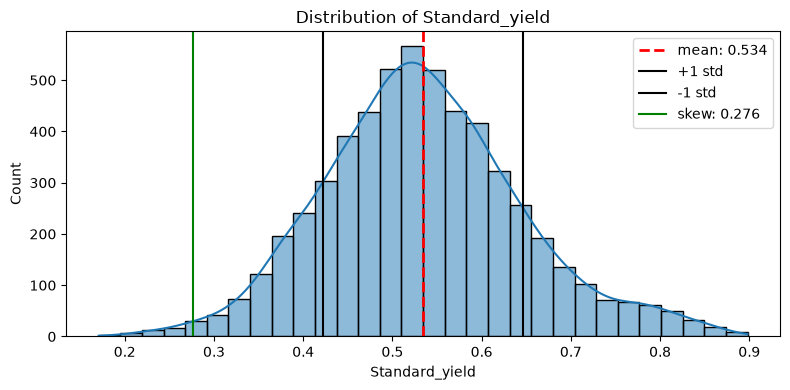

In [44]:
std = field_df['Standard_yield'].std()
mean = round(float(field_df['Standard_yield'].mean()), 3)
skew = round(float(field_df["Standard_yield"].skew()), 3)

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(field_df['Standard_yield'], bins=30, kde=True, ax=ax)
ax.axvline(mean, color='red', linestyle='dashed', linewidth=2, label=f'mean: {mean}')
ax.axvline(mean + std, color='black', linestyle='-', label='+1 std')
ax.axvline(mean - std, color='black', linestyle='-', label='-1 std')
ax.axvline(skew, color = "green", linestyle='-', label= f'skew: {skew}')
ax.set_title('Distribution of Standard_yield')
ax.legend()
plt.tight_layout()
plt.show()

**The standard yield distribution appears approximately normal. The mean (0.534) and median (0.529) are nearly identical, indicating minimal skewness. Additionally, the first and third quartiles are almost equally distant from the median, suggesting a balanced central distribution. The upper and lower tails also extend similar distances from the median (0.369 and 0.358 respectively), providing further evidence of symmetry. These observations support the bell-shaped pattern seen in the histogram and suggest that the variable is approximately normally distributed, although formal normality tests would be required to confirm this statistically**

In [45]:
correlation= (field_df.corr(numeric_only=True)["Standard_yield"]
              .abs().sort_values(ascending=False)
              .drop(["Weather_station", "Field_ID"], 
                    errors = "ignore"))
corr_df = pd.DataFrame(correlation)
corr_df

,Standard_yield
Standard_yield,1.000000
Pollution_level,0.285761
Annual_yield,0.220812
pH,0.196613
Min_temperature_C,0.144233
Elevation,0.129248
Max_temperature_C,0.111649
Longitude,0.085343
Soil_fertility,0.070205
Latitude,0.061724


**Correlation analysis indicates that no individual numeric feature has a strong linear relationship with Standard_yield. The highest absolute correlation is 0.286 (Pollution_level), suggesting that Standard_yield is not explained by a single dominant linear predictor. This also indicates that predictive performance may depend on the combined effects of multiple features and potentially nonlinear relationships, which can be explored using machine learning models.**